In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

arquivos = {
    'area_colhida': '../dados/raw/dados_originais/t5457_pam_area_colhida_2003_2024_ce_br.csv',
    'area_plantada': '../dados/raw/dados_originais/t5457_pam_area_plantada_2003_2024_ce_br.csv',
    'quantidade_produzida': '../dados/raw/dados_originais/t5457_pam_quantidade_produzida_2003_2024_ce_br.csv',
    'rendimento_medio': '../dados/raw/dados_originais/t5457_pam_rendimento_medio_2003_2024_ce_br.csv',
    'valor_producao': '../dados/raw/dados_originais/t5457_pam_valor_producao_2003_2024_ce_br.csv',
}

partes = []
for medida, path in arquivos.items():
    d = pd.read_csv(path, sep=';', encoding='utf-8-sig')
    d['medida'] = medida
    partes.append(d)

df = pd.concat(partes, ignore_index=True)
print('shape:', df.shape)
df.head(50)


shape: (143220, 13)


,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,produto_codigo,produto_nome,valor,medida
0,N1,Brasil,1,Brasil,2003,2003,216,Área colhida,Hectares,40122,Milho (em grão),12965678,area_colhida
1,N1,Brasil,1,Brasil,2004,2004,216,Área colhida,Hectares,40122,Milho (em grão),12410677,area_colhida
2,N1,Brasil,1,Brasil,2005,2005,216,Área colhida,Hectares,40122,Milho (em grão),11549425,area_colhida
3,N1,Brasil,1,Brasil,2006,2006,216,Área colhida,Hectares,40122,Milho (em grão),12613094,area_colhida
4,N1,Brasil,1,Brasil,2007,2007,216,Área colhida,Hectares,40122,Milho (em grão),13767431,area_colhida
5,N1,Brasil,1,Brasil,2008,2008,216,Área colhida,Hectares,40122,Milho (em grão),14444582,area_colhida
6,N1,Brasil,1,Brasil,2009,2009,216,Área colhida,Hectares,40122,Milho (em grão),13654715,area_colhida
7,N1,Brasil,1,Brasil,2010,2010,216,Área colhida,Hectares,40122,Milho (em grão),12678875,area_colhida
8,N1,Brasil,1,Brasil,2011,2011,216,Área colhida,Hectares,40122,Milho (em grão),13218892,area_colhida
9,N1,Brasil,1,Brasil,2012,2012,216,Área colhida,Hectares,40122,Milho (em grão),14198496,area_colhida


In [2]:
print('DTYPES:')
print(df.dtypes)
print()
print('NULOS (NaN nativo) por coluna:')
print(df.isna().sum())
print()
print('DUPLICATAS:', df.duplicated().sum())
print()
print('linhas por arquivo/medida:')
print(df['medida'].value_counts())


DTYPES:
nivel_territorial_codigo    object
nivel_territorial_nome      object
territorio_codigo            int64
territorio_nome             object
ano_codigo                   int64
ano_nome                     int64
variavel_codigo              int64
variavel_nome               object
unidade                     object
produto_codigo               int64
produto_nome                object
valor                       object
medida                      object
dtype: object

NULOS (NaN nativo) por coluna:
nivel_territorial_codigo    0
nivel_territorial_nome      0
territorio_codigo           0
territorio_nome             0
ano_codigo                  0
ano_nome                    0
variavel_codigo             0
variavel_nome               0
unidade                     0
produto_codigo              0
produto_nome                0
valor                       0
medida                      0
dtype: int64

DUPLICATAS: 0

linhas por arquivo/medida:
medida
area_colhida            28644
area_pla

In [3]:
for c in df.columns:
    n = df[c].nunique()
    print(f'{c} ({n} únicos)')
    if n <= 22:
        print(df[c].value_counts().to_string())
    print()


nivel_territorial_codigo (3 únicos)
nivel_territorial_codigo
N6    141680
N1       770
N3       770

nivel_territorial_nome (3 únicos)
nivel_territorial_nome
Município               141680
Brasil                     770
Unidade da Federação       770

territorio_codigo (186 únicos)

territorio_nome (186 únicos)

ano_codigo (22 únicos)
ano_codigo
2003    6510
2004    6510
2005    6510
2006    6510
2007    6510
2008    6510
2009    6510
2010    6510
2011    6510
2012    6510
2013    6510
2014    6510
2015    6510
2016    6510
2017    6510
2018    6510
2019    6510
2020    6510
2021    6510
2022    6510
2023    6510
2024    6510

ano_nome (22 únicos)
ano_nome
2003    6510
2004    6510
2005    6510
2006    6510
2007    6510
2008    6510
2009    6510
2010    6510
2011    6510
2012    6510
2013    6510
2014    6510
2015    6510
2016    6510
2017    6510
2018    6510
2019    6510
2020    6510
2021    6510
2022    6510
2023    6510
2024    6510

variavel_codigo (5 únicos)
variavel_codigo
216  

In [4]:
# coluna 'valor' vem como object -> aqui o IBGE usa "-" como marcador (não "..." como no PIB)
mask_na = pd.to_numeric(df['valor'], errors='coerce').isna()
print('linhas com valor não numérico:', mask_na.sum(), f"({mask_na.sum()/len(df)*100:.1f}%)")
print()

sub = df[mask_na]
print('por medida (arquivo):')
print(sub['medida'].value_counts())
print()
print('por produto_nome:')
print(sub['produto_nome'].value_counts())
print()
print('por nivel_territorial_nome:')
print(sub['nivel_territorial_nome'].value_counts())


linhas com valor não numérico: 31467 (22.0%)

por medida (arquivo):
medida
area_colhida            6314
quantidade_produzida    6314
rendimento_medio        6314
valor_producao          6311
area_plantada           6214
Name: count, dtype: int64

por produto_nome:
produto_nome
Melão               19200
Cana-de-açúcar       6711
Castanha de caju     2052
Mandioca             1798
Banana (cacho)       1530
Milho (em grão)       127
Feijão (em grão)       49
Name: count, dtype: int64

por nivel_territorial_nome:
nivel_territorial_nome
Município    31467
Name: count, dtype: int64


**31.467 linhas (22%) têm `"-"` — muito mais que o PIB (7%). Concentrado em Melão (19.200 linhas) e Cana-de-açúcar (6.711) — culturas de nicho, não cultivadas na maioria dos municípios.**


In [5]:
# causa raiz do N/A: produto nunca cultivado naquele município (estrutural, não defasagem)
d = df[(df['medida'] == 'area_colhida') & (df['nivel_territorial_nome'] == 'Município')].copy()
d['valor_num'] = pd.to_numeric(d['valor'], errors='coerce')

for prod in d['produto_nome'].unique():
    p = d[d['produto_nome'] == prod]
    presenca = p.groupby('territorio_nome')['valor_num'].apply(lambda s: s.notna().sum())
    nunca = (presenca == 0).sum()
    print(f'{prod}: {nunca} de {len(presenca)} municípios NUNCA reportaram valor (todos os anos NA)')


Milho (em grão): 0 de 184 municípios NUNCA reportaram valor (todos os anos NA)
Feijão (em grão): 0 de 184 municípios NUNCA reportaram valor (todos os anos NA)
Mandioca: 2 de 184 municípios NUNCA reportaram valor (todos os anos NA)
Cana-de-açúcar: 39 de 184 municípios NUNCA reportaram valor (todos os anos NA)


Banana (cacho): 6 de 184 municípios NUNCA reportaram valor (todos os anos NA)
Castanha de caju: 7 de 184 municípios NUNCA reportaram valor (todos os anos NA)
Melão: 162 de 184 municípios NUNCA reportaram valor (todos os anos NA)


**N/A aqui é estrutural, não defasagem: 162 de 184 municípios NUNCA cultivaram Melão em 22 anos. Milho e Feijão praticamente sem N/A (0 e 0 municípios nunca reportaram). Não confundir com o "..." do PIB (que é atraso de apuração).**


In [6]:
# tratamento: converter valor para numérico de verdade (NaN em vez de "...")
df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
print(df.dtypes['valor'])
print()
print('N/A por coluna (após tratamento):')
print(df.isna().sum())


float64

N/A por coluna (após tratamento):
nivel_territorial_codigo        0
nivel_territorial_nome          0
territorio_codigo               0
territorio_nome                 0
ano_codigo                      0
ano_nome                        0
variavel_codigo                 0
variavel_nome                   0
unidade                         0
produto_codigo                  0
produto_nome                    0
valor                       31467
medida                          0
dtype: int64


In [7]:
# schema check: ano_codigo == ano_nome? cobertura completa território x ano x produto (por medida)?
print('ano_codigo == ano_nome em todas as linhas:', (df['ano_codigo'] == df['ano_nome']).all())
print()

for medida in df['medida'].unique():
    sub = df[df['medida'] == medida]
    esperado = sub['territorio_codigo'].nunique() * sub['ano_nome'].nunique() * sub['produto_nome'].nunique()
    print(f'{medida}: esperado={esperado}, real={len(sub)}, bate={esperado == len(sub)}')
print()

# padrão do nome: todo município termina em " - CE"?
mun = df[df['nivel_territorial_nome'] == 'Município']
sem_sufixo = mun[~mun['territorio_nome'].str.endswith(' - CE')]['territorio_nome'].unique()
print('municípios sem sufixo " - CE":', sem_sufixo)

# mapeamento código <-> nome
mapa_variavel = df.groupby('variavel_codigo')['variavel_nome'].nunique()
mapa_produto = df.groupby('produto_codigo')['produto_nome'].nunique()
print('variavel_codigo -> variavel_nome sempre 1:1:', (mapa_variavel == 1).all())
print('produto_codigo -> produto_nome sempre 1:1:', (mapa_produto == 1).all())


ano_codigo == ano_nome em todas as linhas: True

area_colhida: esperado=28644, real=28644, bate=True
area_plantada: esperado=28644, real=28644, bate=True
quantidade_produzida: esperado=28644, real=28644, bate=True
rendimento_medio: esperado=28644, real=28644, bate=True
valor_producao: esperado=28644, real=28644, bate=True



municípios sem sufixo " - CE": []
variavel_codigo -> variavel_nome sempre 1:1: True
produto_codigo -> produto_nome sempre 1:1: True


**Schema 100% consistente nos 5 arquivos: linhas batem exato (28.644 = 186 territórios × 22 anos × 7 produtos cada), `ano_codigo == ano_nome` sempre, mapeamento código↔nome 1:1 confirmado.**


In [8]:
# outliers via IQR por produto (medida = valor_producao, só município — escalas entre produtos são muito diferentes)
vp_mun = df[(df['medida'] == 'valor_producao') & (df['nivel_territorial_nome'] == 'Município')]

for prod in vp_mun['produto_nome'].unique():
    sub = vp_mun[vp_mun['produto_nome'] == prod]['valor'].dropna()
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = sub[(sub < limite_inf) | (sub > limite_sup)]
    print(f'{prod}: {len(outliers)} outliers de {len(sub)} ({len(outliers)/len(sub)*100:.1f}%)')


Milho (em grão): 384 outliers de 4019 (9.6%)
Feijão (em grão): 321 outliers de 4038 (7.9%)
Mandioca: 480 outliers de 3688 (13.0%)
Cana-de-açúcar: 425 outliers de 2705 (15.7%)
Banana (cacho): 659 outliers de 3742 (17.6%)
Castanha de caju: 603 outliers de 3625 (16.6%)
Melão: 15 outliers de 208 (7.2%)


**Outliers variam bastante por cultura (7,2% a 17,6%) — mais concentrado que o PIB (11%). Produção agrícola municipal é ainda mais desigual: poucos municípios dominam cada cultura específica.**


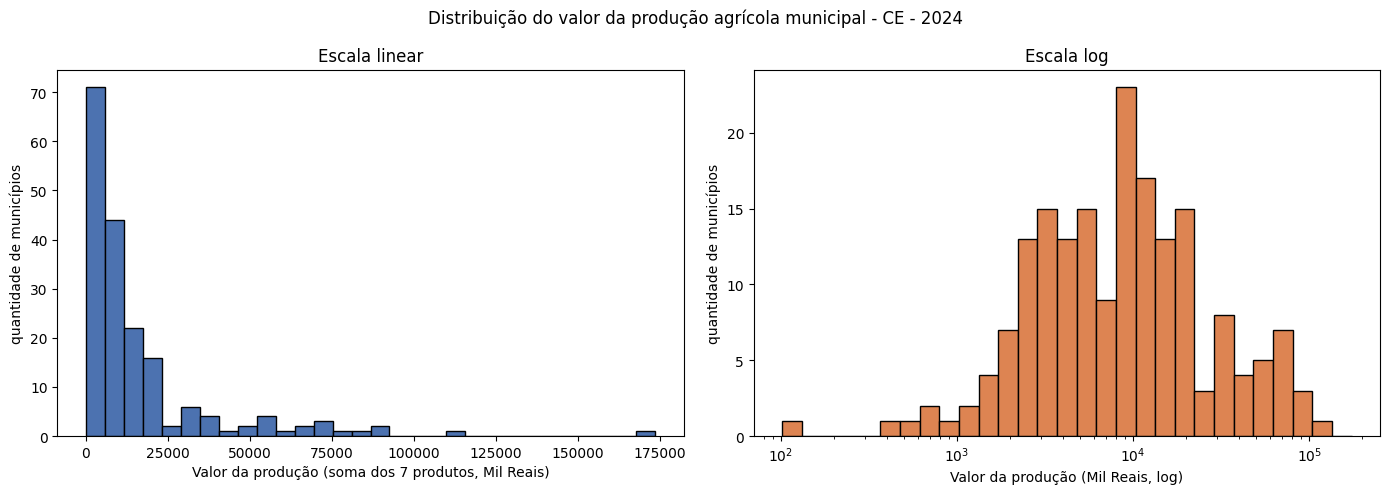

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# distribuição: valor da produção total (soma dos 7 produtos) por município, ano mais recente
total_mun = vp_mun[vp_mun['ano_nome'] == 2024].groupby('territorio_nome')['valor'].sum()
total_mun = total_mun[total_mun > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(total_mun, bins=30, color='#4c72b0', edgecolor='black')
axes[0].set_xlabel('Valor da produção (soma dos 7 produtos, Mil Reais)')
axes[0].set_ylabel('quantidade de municípios')
axes[0].set_title('Escala linear')

axes[1].hist(total_mun, bins=np.logspace(np.log10(total_mun.min()), np.log10(total_mun.max()), 30),
             color='#dd8452', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_xlabel('Valor da produção (Mil Reais, log)')
axes[1].set_ylabel('quantidade de municípios')
axes[1].set_title('Escala log')

fig.suptitle('Distribuição do valor da produção agrícola municipal - CE - 2024')
plt.tight_layout()
plt.show()


**Evolução do valor da produção por produto, Ceará (2003-2024)**

Filtra `df` pra medida `valor_producao` e território agregado `Ceará` (nível estado, não soma dos municípios calculada aqui — vem pronto do SIDRA nesse nível territorial). Ordena por ano e plota uma linha por produto (7 linhas), cada uma em `ax.plot`.

Eixo Y em escala log (`set_yscale("log")`) porque os produtos têm ordens de grandeza bem diferentes de valor de produção (ex: Castanha de caju vs Melão) — sem log, os produtos menores ficariam achatados perto de zero e a variação deles ficaria ilegível no gráfico.

Serve pra visualizar tendência de longo prazo e mudanças de importância relativa entre produtos ao longo dos 22 anos — qual produto cresceu, qual estagnou, qual teve quebra de série.


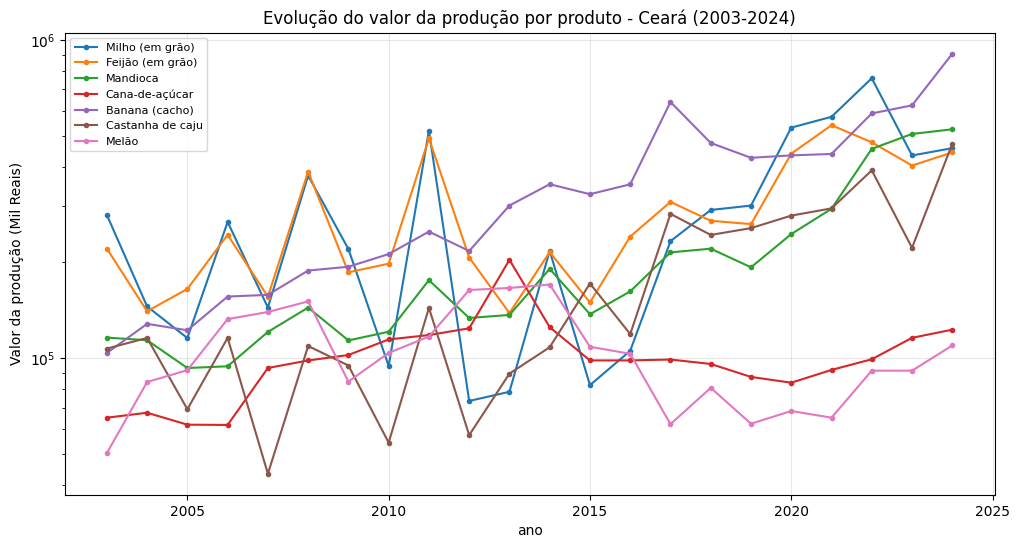

In [10]:
# evolução do valor da produção por produto, Ceará (2003-2024)
ce = df[(df['medida'] == 'valor_producao') & (df['territorio_nome'] == 'Ceará')].sort_values('ano_nome')

fig, ax = plt.subplots(figsize=(12, 6))
for prod in ce['produto_nome'].unique():
    s = ce[ce['produto_nome'] == prod]
    ax.plot(s['ano_nome'], s['valor'], marker='.', label=prod)

ax.set_xlabel('ano')
ax.set_ylabel('Valor da produção (Mil Reais)')
ax.set_title('Evolução do valor da produção por produto - Ceará (2003-2024)')
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='upper left')
plt.show()


In [11]:
# chave de junção com PIB: territorio_codigo bate? intervalo de anos bate?
pib = pd.read_csv('../dados/raw/dados_originais/t5938_pib_agropecuaria_2003_2023_ce_br.csv', sep=';', encoding='utf-8-sig')

print('PAM territorio_codigo == PIB territorio_codigo:', set(df['territorio_codigo']) == set(pib['territorio_codigo']))
print('PAM ano:', df['ano_nome'].min(), '-', df['ano_nome'].max())
print('PIB ano:', pib['ano_nome'].min(), '-', pib['ano_nome'].max())
print('atenção: PAM tem 2024, PIB não — cortar pro intervalo comum (2003-2023) antes de merge')


PAM territorio_codigo == PIB territorio_codigo: True
PAM ano: 2003 - 2024
PIB ano: 2003 - 2023
atenção: PAM tem 2024, PIB não — cortar pro intervalo comum (2003-2023) antes de merge


**`territorio_codigo` bate 100% com o PIB (186=186). Atenção: PAM vai até 2024, PIB só até 2023 — cortar pro intervalo comum (2003-2023) antes de qualquer merge, senão sobra ano sem par.**
